<h2 style="color: red;"> Sentinel2 images exploration and visualisation with Python and Rasterio </h2>

In this exercise, we will cover the following:

 - read Sentinel-2 multispectral bands,
 - create RGB and false-colour composites,
 - save a multiband GeoTIFF,
 - visualise multispectral imagery.

## Import required libraries

In [ ]:
import rasterio as rio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

<p style="color:blue;font-size:13pt">Sentinel-2 products are commonly distributed as compressed archives. The first step is to extract the required files.</p>

In [ ]:
import zipfile   # Open the zip file
fileName='./Input_Data/S2A_MSIL1C_20230815T095031_N0509_R079_T33TXJ_20230815T133204.SAFE.zip'
with zipfile.ZipFile(fileName, 'r') as zip_ref:
    zip_ref.extractall('extracted_files2')  # Extract the files
# The extracted files will be in the 'extracted_files' directory


#### Each Sentinel-2 band represents a different part of the electromagnetic spectrum.

In [ ]:
filePath = ('extracted_files2/S2A_MSIL1C_20230815T095031_N0509_R079_T33TXJ_20230815T133204.SAFE/GRANULE/L1C_T33TXJ_A042547_20230815T095630/IMG_DATA/')
band2= rio.open(filePath+'T33TXJ_20230815T095031_B02.jp2')  # blue
band3 = rio.open(filePath+'T33TXJ_20230815T095031_B03.jp2') # green
band4 = rio.open(filePath+'T33TXJ_20230815T095031_B04.jp2') # red
band8 = rio.open(filePath+'T33TXJ_20230815T095031_B08.jp2') # nir

In [ ]:
band4.profile


In [ ]:
#number of raster bands, number of raster columns, number of raster rows
band4.count, band4.width, band4.height
#type of raster byte,raster sytem of reference,
band4.dtypes[0], band4.crs

In [ ]:
#raster values as matrix array
band4.read(1)


In [ ]:
#raster values as matrix array
import numpy as np
np.max(band4.read(1))

In [ ]:
# Plot the band using imshow
from rasterio.plot import show
fig, ax = plt.subplots()  # Create a figure and a single subplot
cax = ax.imshow(band4.read(1),cmap='gray')  # Display the image, with a colormap of your choice
fig.colorbar(cax, ax=ax)  # Add a colorbar associated with the image
ax.set_title('Band 4 Visualization')  # Set a title for your plot
plt.show()  # Show the plot

In [ ]:
#multiple band representation
#from rasterio import plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
show(band2, ax=ax1, cmap='Blues')# ili plot.show()
show(band3, ax=ax2, cmap='Greens')
show(band4, ax=ax3, cmap='Reds')
fig.tight_layout()

In [ ]:
with rio.open('RGB.tiff','w',driver='Gtiff', width=band4.width, height=band4.height,
              count=3,crs=band4.crs,transform=band4.transform, dtype=band4.dtypes[0]) as rgb:
    rgb.write(band4.read(1),1) # red
    rgb.write(band3.read(1),2) # green
    rgb.write(band2.read(1),3) # blue
    rgb.close()

<h2 style="color: rgb(0,112,192)";">True Color Composition</h2>

<p style="font-size:14pt;">A true-colour composite uses the visible red, green and blue bands to approximate what the human eye would see.</p>

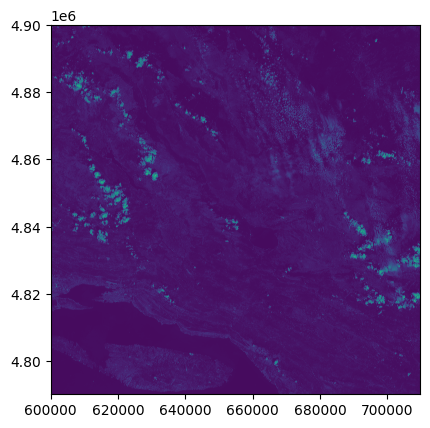

In [19]:
# import true color image
from rasterio.plot import show # if it is not installed
with rio.open("./Output_Data//RGB.tiff", count=3) as src:
    rio.plot.show(src)
    src.close()

In [ ]:
#2nd way of displaying true color image with imshow()

In [ ]:
# Path to the RGB GeoTIFF file

file_path = './Output_Data//RGB.tiff'

# Open the RGB raster file
with rio.open(file_path) as src:
    # Read each band (assuming RGB order)
    red = src.read(1).astype('float64')
    green = src.read(2).astype('float64')
    blue = src.read(3).astype('float64')

    # Normalize the bands to the range 0-1
    red_norm = (red - red.min()) / (red.max() - red.min())
    green_norm = (green - green.min()) / (green.max() - green.min())
    blue_norm = (blue - blue.min()) / (blue.max() - blue.min())

    # Stack the bands into an RGB array
    rgb_norm = np.stack((red_norm, green_norm, blue_norm), axis=-1)

# Visualize the true color image
plt.figure(figsize=(20, 20))
plt.imshow(rgb_norm)
plt.colorbar()  # Optional, may not be necessary for RGB but here for completeness
plt.title('True Color Image (RGB)')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.show()

# Prepare to save the normalized image
    # Update the metadata for the output file
out_meta = src.meta.copy()
out_meta.update({
        "driver": "GTiff",
        "count": 3,  # Three bands: R, G, B
        "dtype": 'float32'  # Change data type to float32 (more typical and broadly compatible)
    })

# Save the normalized RGB image to disk
output_path = './Output_Data/Normalized_RGB.tiff'
with rio.open(output_path, 'w', **out_meta) as dst:
    for i, band in enumerate([red_norm, green_norm, blue_norm], start=1):
        # Convert float64 data to float32 for saving
        dst.write(band.astype(rio.float32), i)


<h2 style="color: rgb(0,111,199);">False Color Composition</h2>
<p style="font-size:14pt;">False-colour composites replace one or more visible bands with infrared information to highlight vegetation and land cover differences.</p>

In [ ]:
nir=(band8.read(1))
red=(band4.read(1)) # red
green=(band3.read(1)) # green

 # Normalize the bands to the range 0-1
red_norm = (red - red.min()) / (red.max() - red.min())
green_norm = (green - green.min()) / (green.max() - green.min())
nir_norm = (nir - nir.min()) / (nir.max() - nir.min())

false_color = np.dstack((nir_norm ,red_norm ,green_norm ))

 # Setup the plot

plt.figure(figsize=(20, 20))
plt.imshow(false_color)
plt.title('False Color Image (RGB)')
plt.xlabel('Column #')
plt.ylabel('Row #')
plt.show()
src.close()


## References

https://hatarilabs.com/ih-en/sentinel2-images-explotarion-and-processing-with-python-and-rasterio